In [2]:
pip install tensorflow keras autokeras


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.7/122.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.2/572.2 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 85.4 MB/s eta 0:00:00


In [3]:
import pandas as pd

# Load the dataset
file_path = '/content/english_french.csv'
data = pd.read_csv(file_path)

# Check the first few rows of the dataset
print(data.head())


  English      French
0     Go.        Va !
1     Go.     Marche.
2     Go.  En route !
3     Go.     Bouge !
4     Hi.     Salut !


In [4]:
# Preprocess the text data
def preprocess_text(text):
    return text.lower()

data['English'] = data['English'].apply(preprocess_text)
data['French'] = data['French'].apply(preprocess_text)

# Check the preprocessed data
print(data.head())


  English      French
0     go.        va !
1     go.     marche.
2     go.  en route !
3     go.     bouge !
4     hi.     salut !


In [5]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Load the dataset
file_path = '/content/english_french.csv'
data = pd.read_csv(file_path)

# Preprocess the text data
def preprocess_text(text):
    return text.lower()

data['English'] = data['English'].apply(preprocess_text)
data['French'] = data['French'].apply(preprocess_text)

# Tokenize the text
english_tokenizer = Tokenizer()
french_tokenizer = Tokenizer()

english_tokenizer.fit_on_texts(data['English'])
french_tokenizer.fit_on_texts(data['French'])

english_sequences = english_tokenizer.texts_to_sequences(data['English'])
french_sequences = french_tokenizer.texts_to_sequences(data['French'])

# Padding sequences
max_english_len = max([len(seq) for seq in english_sequences])
max_french_len = max([len(seq) for seq in french_sequences])

english_padded = pad_sequences(english_sequences, maxlen=max_english_len, padding='post')
french_padded = pad_sequences(french_sequences, maxlen=max_french_len, padding='post')

# Splitting the data
x_train, x_test, y_train, y_test = train_test_split(english_padded, french_padded, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Check the shape of the datasets
print(f'Training set: {x_train.shape}, {y_train.shape}')
print(f'Validation set: {x_val.shape}, {y_val.shape}')
print(f'Test set: {x_test.shape}, {y_test.shape}')


Training set: (147073, 55), (147073, 63)
Validation set: (36769, 55), (36769, 63)
Test set: (45961, 55), (45961, 63)


In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Dense

class MoELayer(tf.keras.layers.Layer):
    def __init__(self, num_experts, units, **kwargs):
        super(MoELayer, self).__init__(**kwargs)
        self.num_experts = num_experts
        self.units = units
        self.experts = [Dense(units, activation='relu') for _ in range(num_experts)]
        self.gating = Dense(num_experts, activation='softmax')

    def call(self, inputs):
        gate_values = self.gating(inputs)  # Shape: [batch_size, timesteps, num_experts]

        # Broadcasting the gating values to match the experts' output shapes
        output = tf.zeros_like(self.experts[0](inputs))  # Initialize output tensor

        for i in range(self.num_experts):
            expert_output = self.experts[i](inputs)  # Shape: [batch_size, timesteps, units]
            gate = tf.expand_dims(gate_values[..., i], axis=-1)  # Shape: [batch_size, timesteps, 1]
            output += gate * expert_output  # Element-wise multiplication and summation

        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], self.units)


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, Input, Dropout
from keras_tuner import HyperModel

class TranslationHyperModel(HyperModel):
    def build(self, hp):
        inputs = Input(shape=(max_english_len,))  # Input shape is based on the max length of English sequences

        # Embedding layer
        x = Embedding(input_dim=len(english_tokenizer.word_index) + 1,
                      output_dim=hp.Int('embedding_dim', min_value=64, max_value=256, step=64))(inputs)

        # MoE layer
        num_experts = hp.Int('num_experts', min_value=2, max_value=8, step=1)
        units = hp.Int('units', min_value=64, max_value=256, step=64)
        x = MoELayer(num_experts=num_experts, units=units)(x)

        # Dropout to prevent overfitting
        x = Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1))(x)

        # LSTM layer for sequence processing
        x = LSTM(units=hp.Int('lstm_units', min_value=64, max_value=256, step=64), return_sequences=False)(x)

        # Output layer for the target language (French)
        outputs = Dense(len(french_tokenizer.word_index) + 1, activation='softmax')(x)

        model = Model(inputs, outputs)
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        return model


In [8]:
import numpy as np

# Ensure the target labels are integer-encoded (not one-hot encoded)
y_train = np.argmax(y_train, axis=-1) if y_train.ndim > 1 else y_train
y_val = np.argmax(y_val, axis=-1) if y_val.ndim > 1 else y_val
y_test = np.argmax(y_test, axis=-1) if y_test.ndim > 1 else y_test

# Confirm the shapes and values
print(y_train.shape)  # Should be (number of examples,)
print(y_train[:5])    # Should be integers


(147073,)
[5 6 2 3 4]


In [9]:
from keras_tuner import RandomSearch
import tensorflow as tf

# Set up the Keras Tuner with the model builder function
tuner = RandomSearch(
    TranslationHyperModel(),
    objective='val_loss',
    max_trials=5,  # Adjust based on available time/resources
    executions_per_trial=1,  # Number of times to evaluate each trial
    directory='tuner_dir',
    project_name='machine_translation_tuning'
)

# Define the callbacks for checkpointing and early stopping
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

# Start the search for the best hyperparameters
tuner.search(x_train, y_train, validation_data=(x_val, y_val), epochs=10, callbacks=[checkpoint, early_stopping])

# Retrieve the best model after tuning
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the test set
test_loss, test_acc = best_model.evaluate(x_test, y_test)
print(f'Test Accuracy: {test_acc}')


Trial 5 Complete [00h 14m 56s]
val_loss: 1.712510585784912

Best val_loss So Far: 1.712510585784912
Total elapsed time: 01h 12m 57s


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1437/1437 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3945 - loss: 1.7141
Test Accuracy: 0.39387741684913635


Epoch 1/10
4594/4597 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4831 - loss: 1.4656
Epoch 1: val_loss improved from inf to 1.71759, saving model to best_model.keras
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 90s 20ms/step - accuracy: 0.4831 - loss: 1.4656 - val_accuracy: 0.4016 - val_loss: 1.7176
Epoch 2/10
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4924 - loss: 1.4360
Epoch 2: val_loss did not improve from 1.71759
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.4924 - loss: 1.4360 - val_accuracy: 0.4007 - val_loss: 1.7210
Epoch 3/10
4596/4597 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5054 - loss: 1.4089
Epoch 3: val_loss did not improve from 1.71759
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.5054 - loss: 1.4089 - val_accuracy: 0.4023 - val_loss: 1.7333
Epoch 4/10
4596/4597 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5184 - loss: 1.3792
Epoch 4: val_loss did not improve from 1.71759
4597/4597 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.

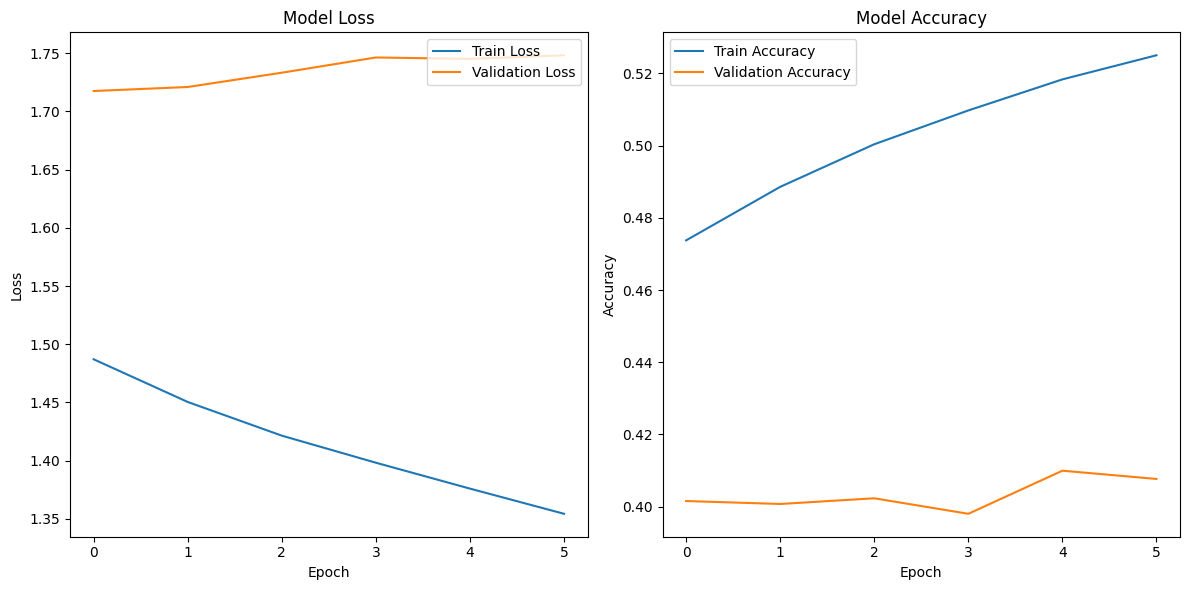

In [31]:
import matplotlib.pyplot as plt

# Assume history is available
history = best_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,  # Example: training for 10 epochs
    callbacks=[checkpoint, early_stopping]
)

# Plotting the training and validation loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [14]:
from tensorflow.keras.layers import Dense
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class MoELayer(tf.keras.layers.Layer):
    def __init__(self, num_experts, units, **kwargs):
        super(MoELayer, self).__init__(**kwargs)
        self.num_experts = num_experts
        self.units = units
        self.experts = [Dense(units, activation='relu') for _ in range(num_experts)]
        self.gating = Dense(num_experts, activation='softmax')

    def build(self, input_shape):
        # Call build on each expert and gating layer with the correct input shape
        for expert in self.experts:
            expert.build(input_shape)
        self.gating.build(input_shape)
        super(MoELayer, self).build(input_shape)

    def call(self, inputs):
        gate_values = self.gating(inputs)  # Shape: [batch_size, timesteps, num_experts]

        # Broadcasting the gating values to match the experts' output shapes
        output = tf.zeros_like(self.experts[0](inputs))  # Initialize output tensor

        for i in range(self.num_experts):
            expert_output = self.experts[i](inputs)  # Shape: [batch_size, timesteps, units]
            gate = tf.expand_dims(gate_values[..., i], axis=-1)  # Shape: [batch_size, timesteps, 1]
            output += gate * expert_output  # Element-wise multiplication and summation

        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], self.units)


In [15]:
best_model.save('best_model.keras')


In [20]:
import numpy as np

# Predict the French translations for the test set
predicted_sequences = best_model.predict(x_test)

# Convert the predicted sequences to the correct format (list of lists)
predicted_sequences = np.argmax(predicted_sequences, axis=-1)

# Ensure that each element in predicted_sequences is a list
predicted_sequences = [seq if isinstance(seq, list) else [seq] for seq in predicted_sequences]

# Convert the predicted sequences back to text
predicted_texts = french_tokenizer.sequences_to_texts(predicted_sequences)

# Ensure y_test is in the correct format (list of lists)
y_test_sequences = [[int(x)] for x in y_test] if y_test.ndim == 1 else y_test.tolist()

# Convert the reference sequences back to text for comparison
reference_texts = french_tokenizer.sequences_to_texts(y_test_sequences)

# Print a few examples to compare predicted and reference translations
for i in range(5):
    print(f"English: {data['English'][i]}")
    print(f"Reference French: {reference_texts[i]}")
    print(f"Predicted French: {predicted_texts[i]}")
    print("\n")


1437/1437 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
English: go.
Reference French: le
Predicted French: de


English: go.
Reference French: je
Predicted French: je


English: go.
Reference French: ne
Predicted French: le


English: go.
Reference French: 
Predicted French: 


English: hi.
Reference French: la
Predicted French: le




In [22]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Smoothing function to handle cases with no higher-order n-grams
smoothing_function = SmoothingFunction().method4

# Calculate BLEU score with smoothing
bleu_scores = []
for reference, predicted in zip(reference_texts, predicted_texts):
    reference = [reference.split()]
    predicted = predicted.split()
    score = sentence_bleu(reference, predicted, smoothing_function=smoothing_function)
    bleu_scores.append(score)

average_bleu = sum(bleu_scores) / len(bleu_scores)
print(f'Average BLEU Score with Smoothing: {average_bleu}')


Average BLEU Score with Smoothing: 0.3584995974848241
